# Reco Cluster Point Selection Testing
# Author: Prabhjot Singh (prabhjot@fnal.gov)
# Purpose: Test reco cluster point selection with min_points cutoff
# This notebook loads a single event and tests selection before/after applying cutoffs

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

np.set_printoptions(linewidth=1000)

In [ ]:
# Configuration for single event testing
SBNDCODE_VERSION          = "v10_06_00"
PROCESS                   = "nu_spill"
apa                       = "apa0"
evt                       = 3             # Single event for testing
min_cluster_charge        = 0             # in ADC (reco uses charge, not energy)
min_reco_points_threshold      = 200           # Minimum number of points in a cluster

# Directories
OUTDIR=Path("/exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode/out/")
SUBDIR="24308437_0"
OUTDIR=OUTDIR / SUBDIR

if PROCESS == "nu_spill":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / PROCESS    
elif PROCESS == "cosmics":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / "cosmics"

NEWOUTDIR     = OUTDIR/"xyz-coordinates"

print(f"Testing event: {evt}")
print(f"Min charge threshold: {min_cluster_charge} ADC")
print(f"Min points threshold: {min_reco_points_threshold}")

Testing event: 3
Min charge threshold: 0 ADC
Min points threshold: 200


In [23]:
def read_reco_coordinates(files):
    """Reads reco coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    return _x, _y, _z, _id, _q

In [24]:
# Load reco coordinates for the event
fx_reco = NEWOUTDIR / str(evt) / f"x_clustering_{apa}.txt"
fy_reco = NEWOUTDIR / str(evt) / f"y_clustering_{apa}.txt"
fz_reco = NEWOUTDIR / str(evt) / f"z_clustering_{apa}.txt"
fid_reco = NEWOUTDIR / str(evt) / f"clusterid_clustering_{apa}.txt"
fq_reco = NEWOUTDIR / str(evt) / f"charge_clustering_{apa}.txt"

reco_files = [fx_reco, fy_reco, fz_reco, fid_reco, fq_reco]
x_reco, y_reco, z_reco, id_reco, q_reco = read_reco_coordinates(reco_files)

# Combine into single array
reco_5d_points = np.column_stack((x_reco, y_reco, z_reco, id_reco, q_reco))
print(f"Initial number of reco points: {len(reco_5d_points)}")

Initial number of reco points: 7296


In [25]:
# Function to apply minimum points cutoff
def apply_min_points_cutoff(reco_points, min_points):
    cluster_counts = {}
    for point in reco_points:
        cluster_id = point[3]
        cluster_counts[cluster_id] = cluster_counts.get(cluster_id, 0) + 1
    
    reco_points = np.array([point for point in reco_points if cluster_counts[point[3]] >= min_points])
    return reco_points

In [26]:
# Count points per cluster BEFORE min_points cutoff
cluster_counts_before = {}
for point in reco_5d_points:
    cluster_id = point[3]
    cluster_counts_before[cluster_id] = cluster_counts_before.get(cluster_id, 0) + 1

print(f"BEFORE min_points cutoff:")
print(f"Number of clusters: {len(cluster_counts_before)}")
print(f"\nPoints per cluster:")
for cluster_id, count in sorted(cluster_counts_before.items(), key=lambda x: x[1], reverse=True):
    print(f"  Cluster {cluster_id:7.1f}: {count:5d} points")

BEFORE min_points cutoff:
Number of clusters: 12

Points per cluster:
  Cluster    11.0:  2799 points
  Cluster     4.0:  1641 points
  Cluster     8.0:   880 points
  Cluster     7.0:   847 points
  Cluster     2.0:   423 points
  Cluster    10.0:   260 points
  Cluster     3.0:   170 points
  Cluster     9.0:   124 points
  Cluster     6.0:    56 points
  Cluster     5.0:    48 points
  Cluster     1.0:    30 points
  Cluster     0.0:    18 points


In [27]:
# Apply minimum points cutoff
print(f"Applying min_points cutoff: {min_reco_points_threshold} points")
print(f"\nBEFORE min_points cutoff:")
print(f"Number of clusters: {len(cluster_counts_before)}")
print(f"Points before min_points cutoff: {len(reco_5d_points)}")
reco_points_after_minpoints = apply_min_points_cutoff(reco_5d_points, min_reco_points_threshold)

print ("\n")
print(f"Clusters after min_points cutoff: {len(set(reco_points_after_minpoints[:, 3]))}")
print(f"Points after min_points cutoff: {len(reco_points_after_minpoints)}")
print ("\n")
print(f"Clustering removed: {len(set(reco_5d_points[:, 3])) - len(set(reco_points_after_minpoints[:, 3]))} clusters")
print(f"Points removed: {len(reco_5d_points) - len(reco_points_after_minpoints)}")

Applying min_points cutoff: 200 points

BEFORE min_points cutoff:
Number of clusters: 12
Points before min_points cutoff: 7296


Clusters after min_points cutoff: 6
Points after min_points cutoff: 6850


Clustering removed: 6 clusters
Points removed: 446


In [28]:
# Count points per cluster AFTER min_points cutoff
cluster_counts_after = {}
for point in reco_points_after_minpoints:
    cluster_id = point[3]
    cluster_counts_after[cluster_id] = cluster_counts_after.get(cluster_id, 0) + 1

print(f"AFTER min_points cutoff:")
print(f"Number of clusters: {len(cluster_counts_after)}")
print(f"\nPoints per cluster:")
for cluster_id, count in sorted(cluster_counts_after.items(), key=lambda x: x[1], reverse=True):
    print(f"  Cluster {cluster_id:7.1f}: {count:5d} points")

AFTER min_points cutoff:
Number of clusters: 6

Points per cluster:
  Cluster    11.0:  2799 points
  Cluster     4.0:  1641 points
  Cluster     8.0:   880 points
  Cluster     7.0:   847 points
  Cluster     2.0:   423 points
  Cluster    10.0:   260 points


In [29]:
# Define color map for all clusters (to be used in all visualizations)
colors_all = plt.cm.tab20(np.linspace(0, 1, len(cluster_counts_before)))
sorted_cluster_ids = sorted(cluster_counts_before.keys())
color_map = {cluster_id: colors_all[idx] for idx, cluster_id in enumerate(sorted_cluster_ids)}

print(f"Color map created for {len(color_map)} clusters")

Color map created for 12 clusters


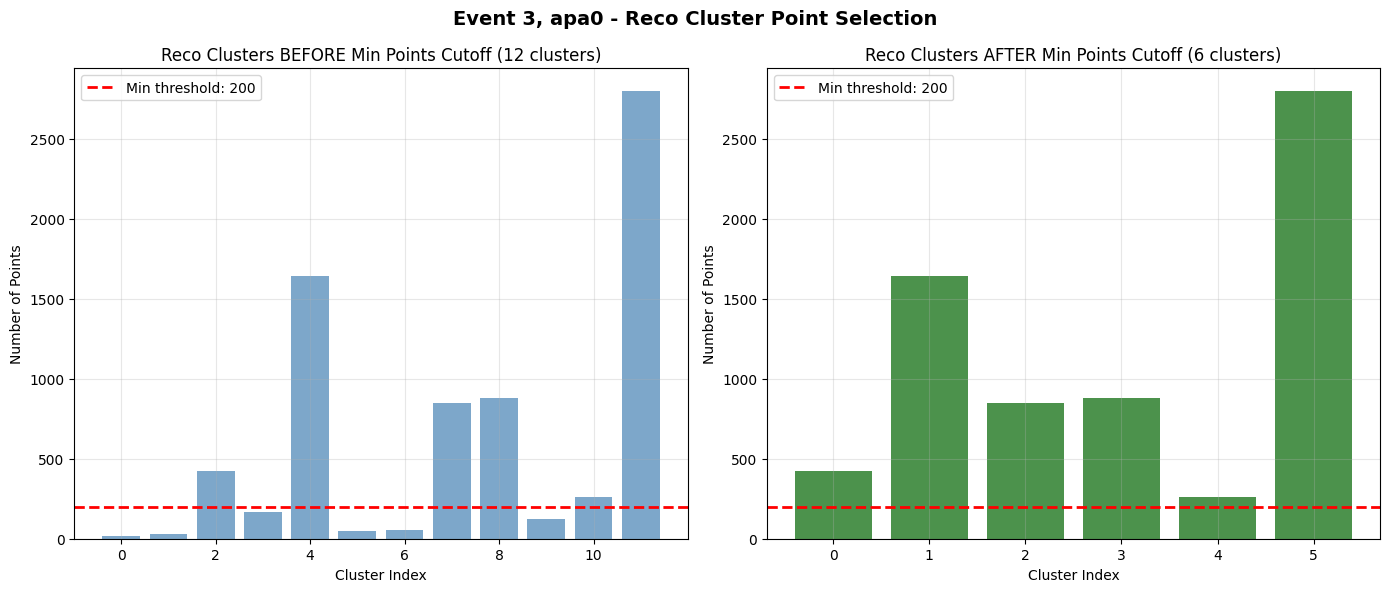


Summary:
  Clusters BEFORE cutoff: 12
  Clusters AFTER cutoff:  6
  Clusters removed: 6


In [30]:
# Create bar plots comparing before and after min_points cutoff
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before cutoff
clusters_before = list(cluster_counts_before.keys())
counts_before = list(cluster_counts_before.values())
axes[0].bar(range(len(clusters_before)), counts_before, color='steelblue', alpha=0.7)
axes[0].axhline(y=min_reco_points_threshold, color='red', linestyle='--', linewidth=2, label=f'Min threshold: {min_reco_points_threshold}')
axes[0].set_xlabel('Cluster Index')
axes[0].set_ylabel('Number of Points')
axes[0].set_title(f'Reco Clusters BEFORE Min Points Cutoff ({len(clusters_before)} clusters)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After cutoff
clusters_after = list(cluster_counts_after.keys())
counts_after = list(cluster_counts_after.values())
axes[1].bar(range(len(clusters_after)), counts_after, color='darkgreen', alpha=0.7)
axes[1].axhline(y=min_reco_points_threshold, color='red', linestyle='--', linewidth=2, label=f'Min threshold: {min_reco_points_threshold}')
axes[1].set_xlabel('Cluster Index')
axes[1].set_ylabel('Number of Points')
axes[1].set_title(f'Reco Clusters AFTER Min Points Cutoff ({len(clusters_after)} clusters)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Event {evt}, {apa} - Reco Cluster Point Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show(block=False)

print(f"\nSummary:")
print(f"  Clusters BEFORE cutoff: {len(cluster_counts_before)}")
print(f"  Clusters AFTER cutoff:  {len(cluster_counts_after)}")
print(f"  Clusters removed: {len(cluster_counts_before) - len(cluster_counts_after)}")


Example of removed cluster:
  Cluster ID: 3.0
  Points in cluster: 170 (threshold: 200)
  Status: REMOVED (less than 200 points)


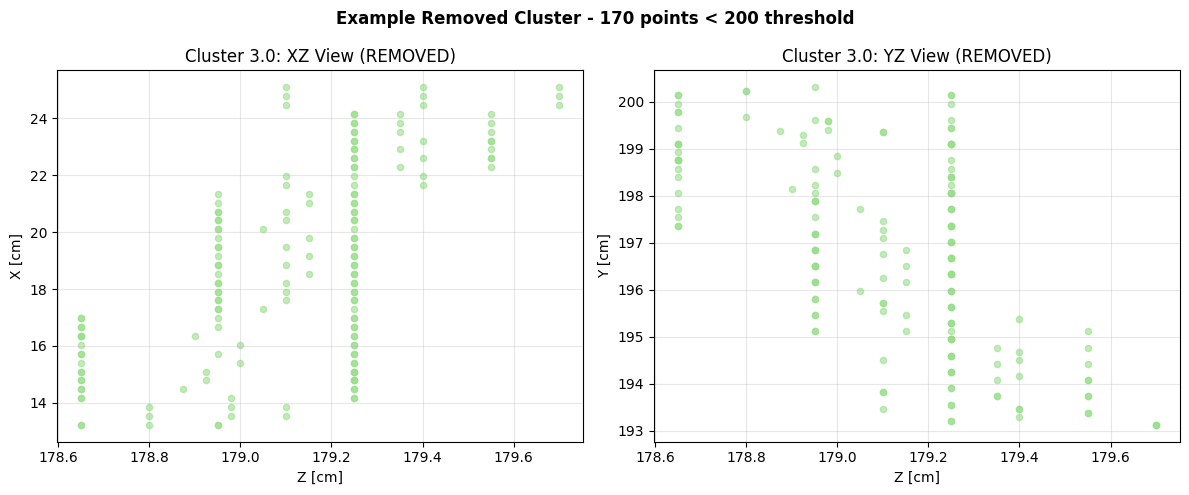


Example of kept cluster:
  Cluster ID: 11.0
  Points in cluster: 2799 (threshold: 200)
  Status: KEPT (>= 200 points)


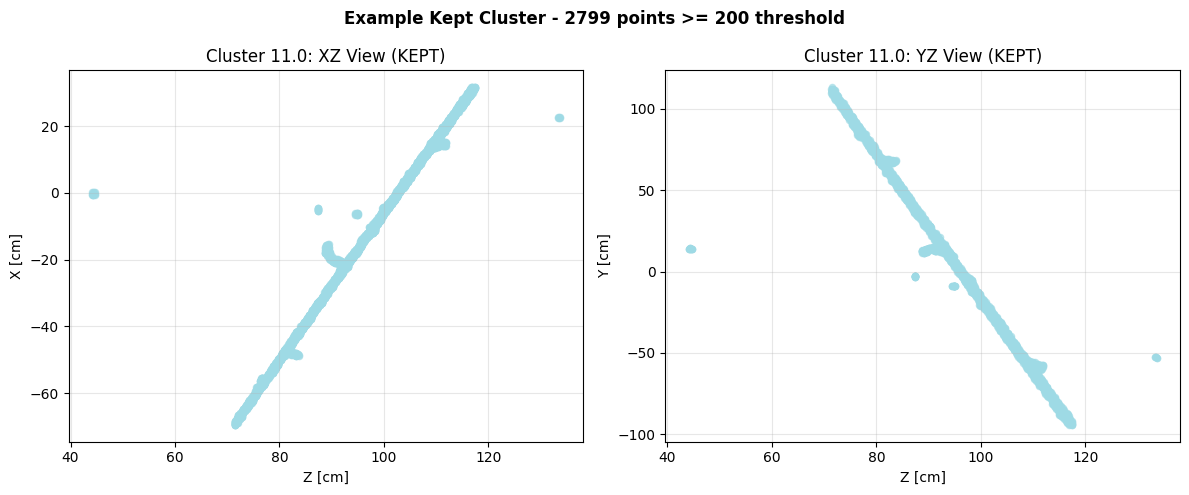

In [31]:
# Show example of a cluster that was removed
removed_clusters = set(cluster_counts_before.keys()) - set(cluster_counts_after.keys())

if removed_clusters:
    # Pick the largest removed cluster for visualization
    largest_removed = max(removed_clusters, key=lambda x: cluster_counts_before[x])
    count_removed = cluster_counts_before[largest_removed]
    color_removed = color_map[largest_removed]
    
    print(f"\nExample of removed cluster:")
    print(f"  Cluster ID: {largest_removed}")
    print(f"  Points in cluster: {count_removed} (threshold: {min_reco_points_threshold})")
    print(f"  Status: REMOVED (less than {min_reco_points_threshold} points)")
    
    # Get points from this cluster
    example_points = reco_5d_points[reco_5d_points[:, 3] == largest_removed]
    
    # Plot the example cluster
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # XZ view
    axes[0].scatter(example_points[:, 2], example_points[:, 0], s=20, alpha=0.6, color=color_removed)
    axes[0].set_xlabel('Z [cm]')
    axes[0].set_ylabel('X [cm]')
    axes[0].set_title(f'Cluster {largest_removed}: XZ View (REMOVED)')
    axes[0].grid(True, alpha=0.3)
    
    # YZ view
    axes[1].scatter(example_points[:, 2], example_points[:, 1], s=20, alpha=0.6, color=color_removed)
    axes[1].set_xlabel('Z [cm]')
    axes[1].set_ylabel('Y [cm]')
    axes[1].set_title(f'Cluster {largest_removed}: YZ View (REMOVED)')
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Example Removed Cluster - {count_removed} points < {min_reco_points_threshold} threshold', fontweight='bold')
    plt.tight_layout()
    plt.show(block=False)
else:
    print("No clusters were removed by the min_points cutoff.")

# Show example of a cluster that was kept
kept_clusters = set(cluster_counts_after.keys())
if kept_clusters:
    largest_kept = max(kept_clusters, key=lambda x: cluster_counts_after[x])
    count_kept = cluster_counts_after[largest_kept]
    color_kept = color_map[largest_kept]
    
    print(f"\nExample of kept cluster:")
    print(f"  Cluster ID: {largest_kept}")
    print(f"  Points in cluster: {count_kept} (threshold: {min_reco_points_threshold})")
    print(f"  Status: KEPT (>= {min_reco_points_threshold} points)")
    
    # Get points from this cluster
    example_points_kept = reco_points_after_minpoints[reco_points_after_minpoints[:, 3] == largest_kept]
    
    # Plot the example cluster
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # XZ view
    axes[0].scatter(example_points_kept[:, 2], example_points_kept[:, 0], s=20, alpha=0.6, color=color_kept)
    axes[0].set_xlabel('Z [cm]')
    axes[0].set_ylabel('X [cm]')
    axes[0].set_title(f'Cluster {largest_kept}: XZ View (KEPT)')
    axes[0].grid(True, alpha=0.3)
    
    # YZ view
    axes[1].scatter(example_points_kept[:, 2], example_points_kept[:, 1], s=20, alpha=0.6, color=color_kept)
    axes[1].set_xlabel('Z [cm]')
    axes[1].set_ylabel('Y [cm]')
    axes[1].set_title(f'Cluster {largest_kept}: YZ View (KEPT)')
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Example Kept Cluster - {count_kept} points >= {min_reco_points_threshold} threshold', fontweight='bold')
    plt.tight_layout()
    plt.show(block=False)

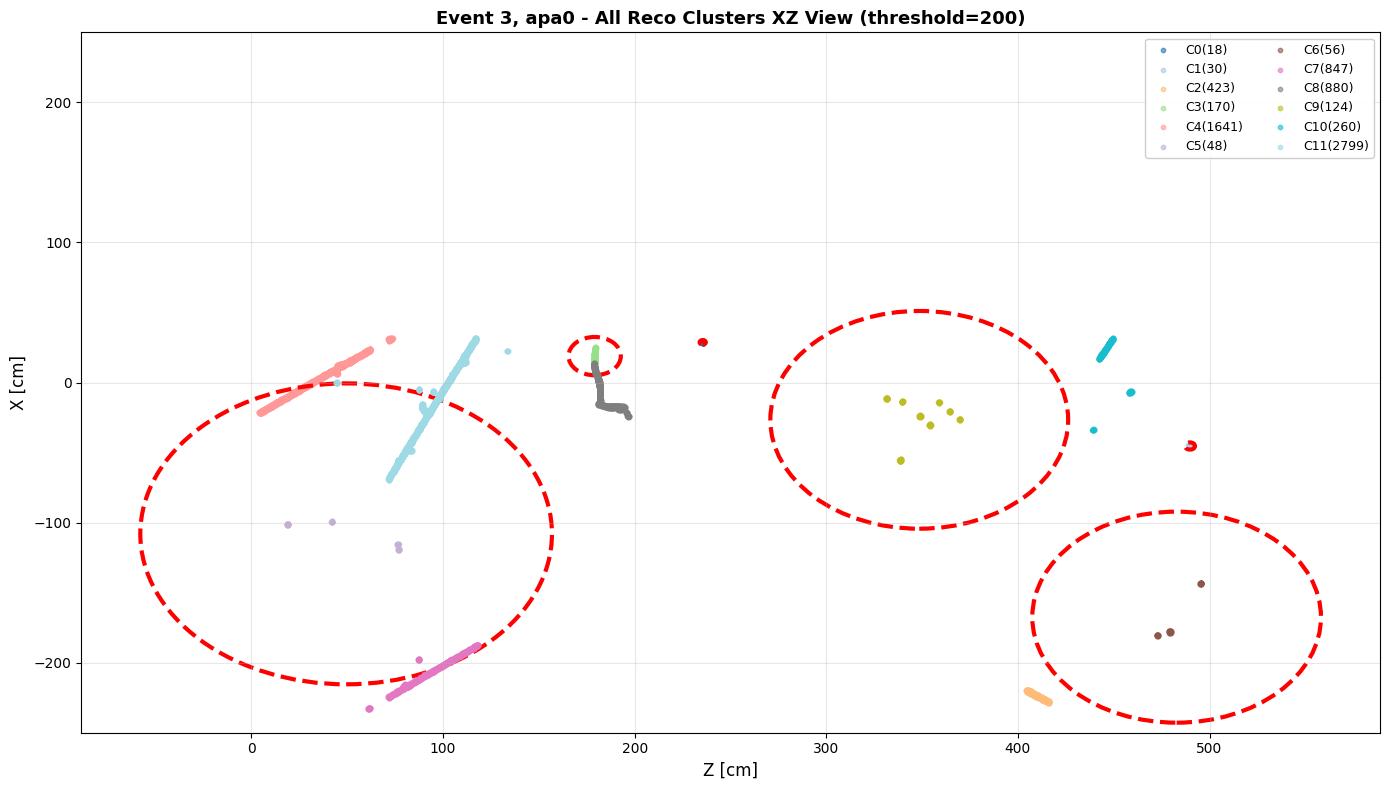


XZ View Summary:
Total clusters: 12
Removed clusters (with red circle highlight): 6
  - Cluster 0: 18 points
  - Cluster 1: 30 points
  - Cluster 3: 170 points
  - Cluster 5: 48 points
  - Cluster 6: 56 points
  - Cluster 9: 124 points
Kept clusters: 6


In [32]:
# Draw ALL clusters in XZ view with circle highlighting removed clusters
from matplotlib.patches import Circle

# Group clusters
def group_clusters_by_id(points):
    clusters = {}
    for point in points:
        cluster_id = point[3]
        if cluster_id not in clusters:
            clusters[cluster_id] = []
        clusters[cluster_id].append(point)
    return clusters

clusters_before = group_clusters_by_id(reco_5d_points)
clusters_after = group_clusters_by_id(reco_points_after_minpoints)

# Find removed clusters
removed_clusters = set(clusters_before.keys()) - set(clusters_after.keys())

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Draw all clusters with original colors
for idx, (cluster_id, points) in enumerate(sorted(clusters_before.items())):
    points_arr = np.array(points)
    count = len(points_arr)
    
    # Use original color for all clusters
    ax.scatter(points_arr[:, 2], points_arr[:, 0], s=10, alpha=0.6, 
              label=f'C{cluster_id:.0f}({count})', color=color_map[cluster_id])
    
    # Add circle around removed clusters only (without changing color)
    if cluster_id in removed_clusters:
        z_center = np.mean(points_arr[:, 2])
        x_center = np.mean(points_arr[:, 0])
        z_std = np.std(points_arr[:, 2])
        x_std = np.std(points_arr[:, 0])
        radius = np.sqrt(z_std**2 + x_std**2) * 4  # Circle (2x larger)
        
        circle = Circle((z_center, x_center), radius, fill=False, edgecolor='red', 
                       linewidth=3, linestyle='--')
        ax.add_patch(circle)

ax.set_xlabel('Z [cm]', fontsize=12)
ax.set_ylabel('X [cm]', fontsize=12)
ax.set_title(f'Event {evt}, {apa} - All Reco Clusters XZ View (threshold={min_reco_points_threshold})', 
            fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.ylim(-250, 250)
plt.show(block=False)

print(f"\nXZ View Summary:")
print(f"Total clusters: {len(clusters_before)}")
print(f"Removed clusters (with red circle highlight): {len(removed_clusters)}")
if removed_clusters:
    for cluster_id in removed_clusters:
        print(f"  - Cluster {cluster_id:.0f}: {len(clusters_before[cluster_id])} points")
print(f"Kept clusters: {len(clusters_after)}")

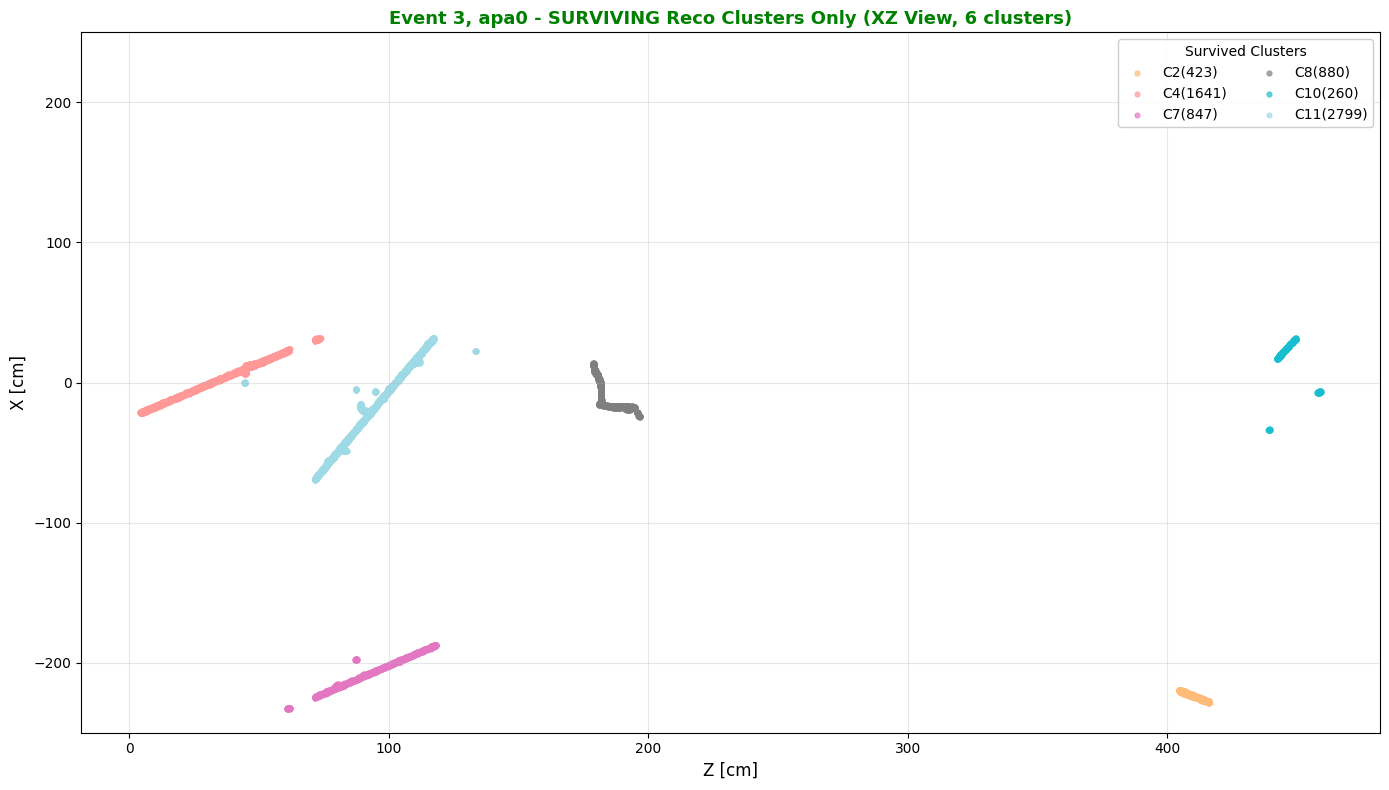


Surviving Reco Clusters Summary:
Total surviving clusters: 6
Total surviving points: 6850

Surviving cluster details:
  - Cluster     2.0:   423 points
  - Cluster     4.0:  1641 points
  - Cluster     7.0:   847 points
  - Cluster     8.0:   880 points
  - Cluster    10.0:   260 points
  - Cluster    11.0:  2799 points


In [33]:
# Draw only SURVIVING clusters (after min_points cutoff) in single display
fig, ax = plt.subplots(figsize=(14, 8))

# Draw only surviving clusters using color_map
for cluster_id in sorted(clusters_after.keys()):
    points = clusters_after[cluster_id]
    points_arr = np.array(points)
    count = len(points_arr)
    color = color_map[cluster_id]  # Use color from global color_map
    
    ax.scatter(points_arr[:, 2], points_arr[:, 0], s=15, alpha=0.7, 
              label=f'C{cluster_id:.0f}({count})', color=color, linewidth=0.5)

ax.set_xlabel('Z [cm]', fontsize=12)
ax.set_ylabel('X [cm]', fontsize=12)
ax.set_title(f'Event {evt}, {apa} - SURVIVING Reco Clusters Only (XZ View, {len(clusters_after)} clusters)', 
            fontsize=13, fontweight='bold', color='green')
ax.legend(loc='upper right', fontsize=10, ncol=2, framealpha=0.95, title='Survived Clusters')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.ylim(-250, 250)
plt.show(block=False)

print(f"\nSurviving Reco Clusters Summary:")
print(f"Total surviving clusters: {len(clusters_after)}")
print(f"Total surviving points: {len(reco_points_after_minpoints)}")
print(f"\nSurviving cluster details:")
for cluster_id in sorted(clusters_after.keys()):
    count = len(clusters_after[cluster_id])
    print(f"  - Cluster {cluster_id:7.1f}: {count:5d} points")